In [1]:
# cell 1 — imports and paths
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import shutil, yaml, random
from collections import Counter

PROJECT_ROOT   = Path('..')
CORROSION_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'corrosion-detect' / 'corrosion detect'
IMG_DIR        = CORROSION_ROOT / 'images'
LBL_DIR        = CORROSION_ROOT / 'labels'
YOLO_DATA_DIR  = PROJECT_ROOT / 'data' / 'corrosion_yolo'   # structured dataset for YOLO
REPORTS_DIR    = PROJECT_ROOT / 'reports'

imgs = sorted(list(IMG_DIR.rglob('*.jpeg')) +
              list(IMG_DIR.rglob('*.jpg'))  +
              list(IMG_DIR.rglob('*.png')))
lbls = sorted(LBL_DIR.rglob('*.txt'))

print(f'Images : {len(imgs)}')
print(f'Labels : {len(lbls)}')

# Check every image has a matching label
img_stems = {p.stem for p in imgs}
lbl_stems = {p.stem for p in lbls}
print(f'\nImages without labels : {len(img_stems - lbl_stems)}')
print(f'Labels without images : {len(lbl_stems - img_stems)}')

Images : 268
Labels : 268

Images without labels : 0
Labels without images : 0


Class ID distribution in labels:
  class 1 : 2132 boxes

Boxes per image:
  min    : 0
  max    : 25
  mean   : 8.0
  total  : 2132 bounding boxes


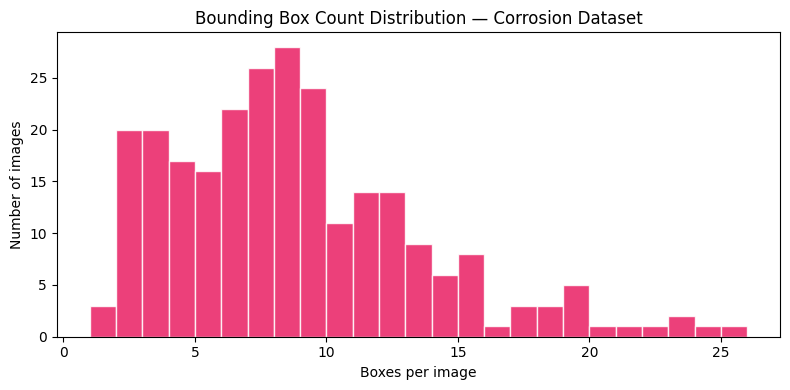

In [2]:
# cell 2 — inspect labels: class ids, box counts per image
class_ids_all = []
boxes_per_img = []

for lbl_path in lbls:
    lines = lbl_path.read_text().strip().splitlines()
    lines = [l for l in lines if l.strip()]
    boxes_per_img.append(len(lines))
    for line in lines:
        class_ids_all.append(int(line.split()[0]))

class_counts = Counter(class_ids_all)
print('Class ID distribution in labels:')
for cid, count in sorted(class_counts.items()):
    print(f'  class {cid} : {count} boxes')

print(f'\nBoxes per image:')
print(f'  min    : {min(boxes_per_img)}')
print(f'  max    : {max(boxes_per_img)}')
print(f'  mean   : {np.mean(boxes_per_img):.1f}')
print(f'  total  : {sum(boxes_per_img)} bounding boxes')

# Distribution histogram
plt.figure(figsize=(8, 4))
plt.hist(boxes_per_img, bins=range(1, max(boxes_per_img)+2),
         color='#E91E63', edgecolor='white', alpha=0.85)
plt.xlabel('Boxes per image')
plt.ylabel('Number of images')
plt.title('Bounding Box Count Distribution — Corrosion Dataset')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'corrosion_box_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

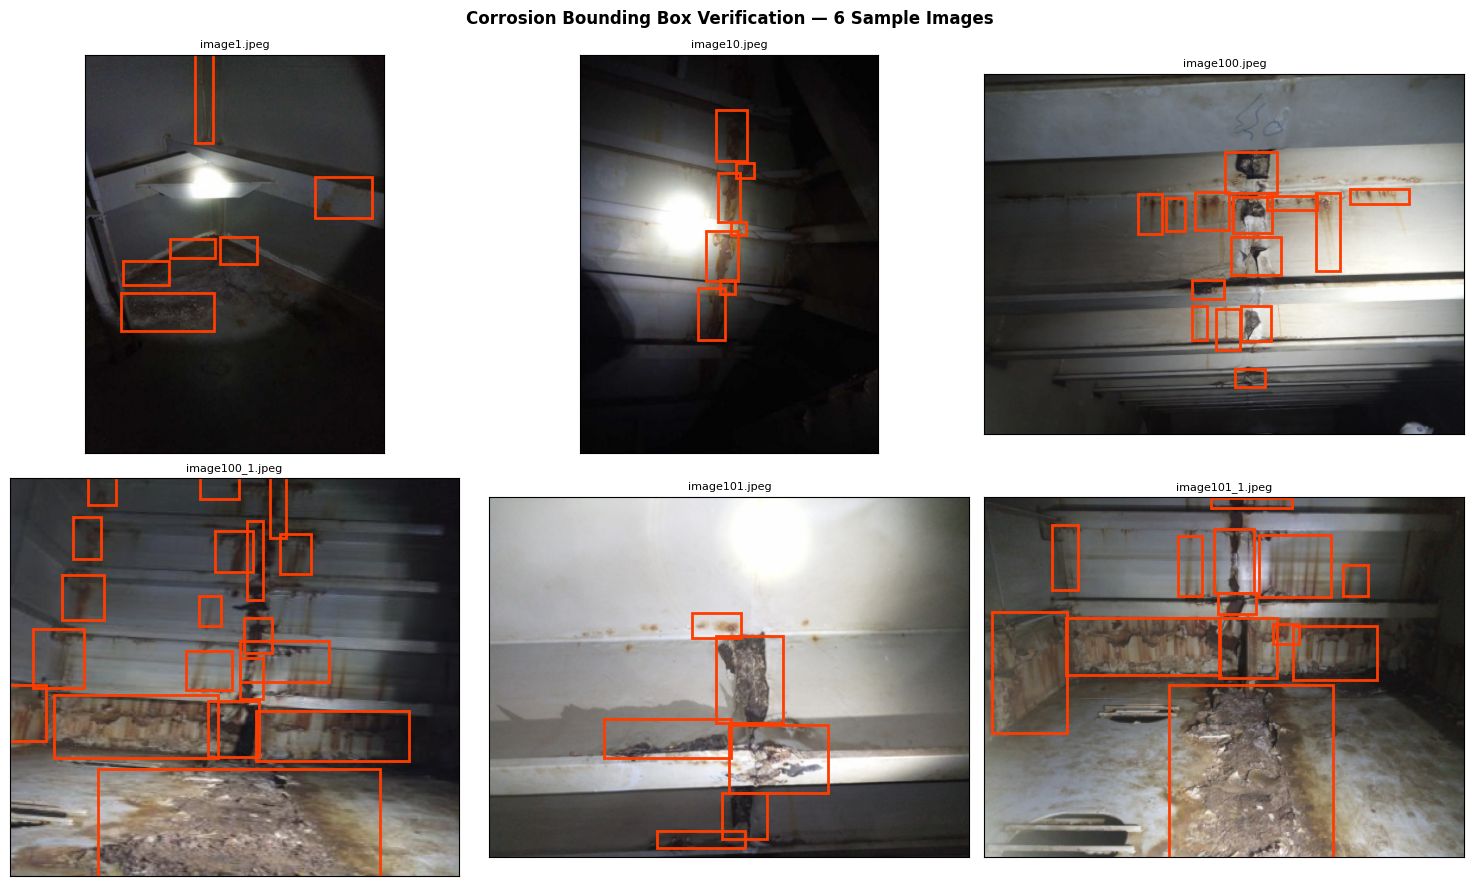

In [3]:
# cell 3 — draw YOLO boxes on 6 sample images to visually verify labels

def draw_yolo_boxes(img_path, lbl_path, ax, title=''):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img)

    lines = lbl_path.read_text().strip().splitlines()
    for line in lines:
        if not line.strip():
            continue
        parts = line.split()
        _, cx, cy, bw, bh = float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        # Convert YOLO normalized → pixel coords
        x1 = (cx - bw / 2) * w
        y1 = (cy - bh / 2) * h
        rect = patches.Rectangle((x1, y1), bw * w, bh * h,
                                  linewidth=2, edgecolor='#FF3D00', facecolor='none')
        ax.add_patch(rect)

    ax.set_title(title, fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

sample_pairs = list(zip(
    sorted(imgs)[:6],
    [LBL_DIR / (p.stem + '.txt') for p in sorted(imgs)[:6]]
))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Corrosion Bounding Box Verification — 6 Sample Images',
             fontsize=12, fontweight='bold')

for ax, (img_p, lbl_p) in zip(axes.flat, sample_pairs):
    if lbl_p.exists():
        draw_yolo_boxes(img_p, lbl_p, ax, title=img_p.name)
    else:
        ax.set_title(f'{img_p.name} — NO LABEL', color='red')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'corrosion_box_samples.png', dpi=120, bbox_inches='tight')
plt.show()

In [4]:
# cell 4 — 80/20 split, build YOLO dataset folder structure

random.seed(42)
paired = [(img, LBL_DIR / (img.stem + '.txt'))
          for img in imgs if (LBL_DIR / (img.stem + '.txt')).exists()]

random.shuffle(paired)
split_idx  = int(len(paired) * 0.8)
train_pairs = paired[:split_idx]
val_pairs   = paired[split_idx:]

print(f'Total paired : {len(paired)}')
print(f'Train        : {len(train_pairs)}')
print(f'Val          : {len(val_pairs)}')

# Build YOLO-expected folder structure:
# corrosion_yolo/
#   images/train/   images/val/
#   labels/train/   labels/val/
for split in ['train', 'val']:
    (YOLO_DATA_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DATA_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

def copy_pairs(pairs, split):
    for img_p, lbl_p in pairs:
        shutil.copy(img_p, YOLO_DATA_DIR / 'images' / split / img_p.name)
        shutil.copy(lbl_p, YOLO_DATA_DIR / 'labels' / split / lbl_p.name)

copy_pairs(train_pairs, 'train')
copy_pairs(val_pairs,   'val')

print('\nFolder structure built:')
for split in ['train', 'val']:
    n_img = len(list((YOLO_DATA_DIR / 'images' / split).iterdir()))
    n_lbl = len(list((YOLO_DATA_DIR / 'labels' / split).iterdir()))
    print(f'  {split:5s}  images: {n_img}  labels: {n_lbl}')

Total paired : 268
Train        : 214
Val          : 54

Folder structure built:
  train  images: 214  labels: 214
  val    images: 54  labels: 54


In [5]:
# cell 5 — write YOLO dataset.yaml
# IMPORTANT: we need to know the class id from Cell 2 output.
# If all boxes have class_id=1, we define nc=2 with a dummy class 0.
# If all boxes have class_id=0, we define nc=1 with class 'corrosion'.

# Read from Cell 2 output — change nc and names accordingly
UNIQUE_CLASS_IDS = sorted(class_counts.keys())
print(f'Unique class IDs in dataset: {UNIQUE_CLASS_IDS}')

# Build class name list — index = class_id
# If ids are [0] → single class corrosion
# If ids are [1] → YOLO needs names[1], so we pad with a dummy at index 0
if UNIQUE_CLASS_IDS == [0]:
    nc    = 1
    names = ['corrosion']
elif UNIQUE_CLASS_IDS == [1]:
    nc    = 2
    names = ['background', 'corrosion']
else:
    nc    = max(UNIQUE_CLASS_IDS) + 1
    names = ['background'] * nc
    names[UNIQUE_CLASS_IDS[-1]] = 'corrosion'

dataset_cfg = {
    'path':  str(YOLO_DATA_DIR.resolve()),
    'train': 'images/train',
    'val':   'images/val',
    'nc':    nc,
    'names': names,
}

yaml_path = YOLO_DATA_DIR / 'dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_cfg, f, default_flow_style=False, sort_keys=False)

print(f'\ndataset.yaml written → {yaml_path}')
print(yaml.dump(dataset_cfg, default_flow_style=False, sort_keys=False))

Unique class IDs in dataset: [1]

dataset.yaml written → ..\data\corrosion_yolo\dataset.yaml
path: C:\Users\gaura\OneDrive - Shri Vile Parle Kelavani Mandal\self_projects\coatings-cv-project\data\corrosion_yolo
train: images/train
val: images/val
nc: 2
names:
- background
- corrosion



In [6]:
# cell 6 — train YOLOv8n
# Run this once in terminal first if not installed:
#   pip install ultralytics

from ultralytics import YOLO

model = YOLO('yolov8n.pt')   # downloads ~6MB nano model

results = model.train(
    data    = str(yaml_path),
    epochs  = 50,
    imgsz   = 640,
    batch   = 8,
    device  = 'cpu',
    project = str(PROJECT_ROOT / 'models' / 'yolo_runs'),
    name    = 'corrosion_v1',
    exist_ok= True,
    patience= 15,             # early stopping — stops if no improvement for 15 epochs
    save    = True,
    plots   = True,           # Ultralytics auto-generates training plots
    verbose = True,
)

print('\nTraining complete.')
print(f'Best model → {results.save_dir}/weights/best.pt')

Ultralytics 8.4.33  Python-3.11.15 torch-2.11.0+cpu CPU (AMD Ryzen 5 5500U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\data\corrosion_yolo\dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=corrosion_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

C:\Users\gaura\mambaforge\envs\coating-cv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


MLflow: logging run_id(bdf92d1c85a7444c8ca3c560b4f75dcc) to runs\mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs\mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to C:\Users\gaura\OneDrive - Shri Vile Parle Kelavani Mandal\self_projects\coatings-cv-project\notebooks\runs\models\yolo_runs\corrosion_v1
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/50         0G      2.548      3.252      1.936         14        640: 100% ━━━━━━━━━━━━ 27/27 5.8s/it 2:364.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.3s/it 13.2s6.2ss
                   all         52        401     0.0263      0.519     0.0751     0.0218

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50         0G      2.407      

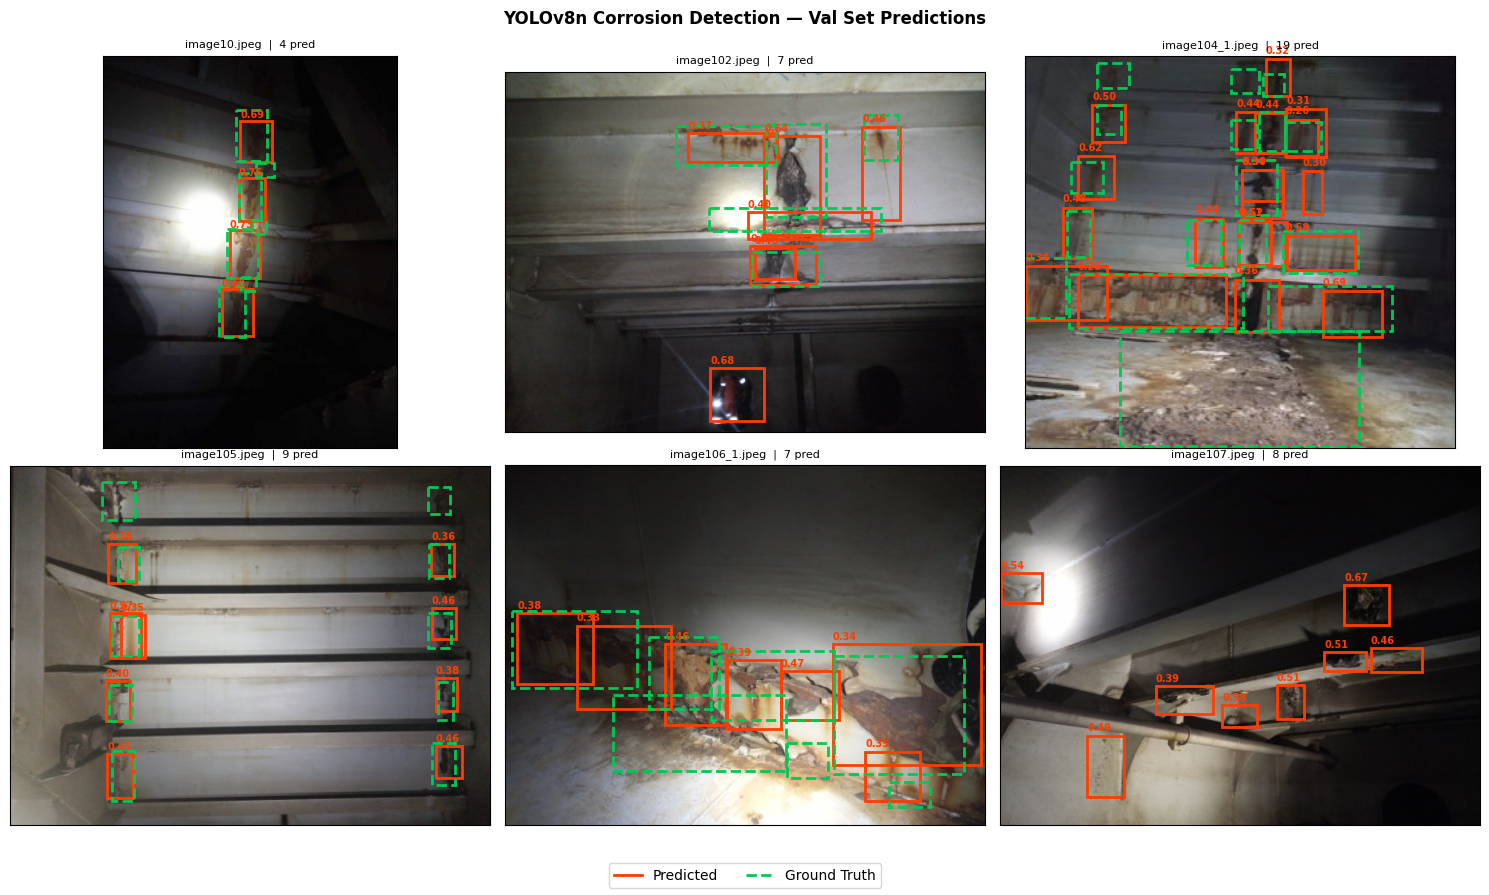

Saved → reports/corrosion_detections.png


In [7]:
# cell 7 — load best model and visualise predictions on val images
from ultralytics import YOLO
import cv2, matplotlib.pyplot as plt, matplotlib.patches as patches
import numpy as np
from pathlib import Path

BEST_MODEL_PATH = Path(r'../notebooks/runs/models/yolo_runs/corrosion_v1/weights/best.pt')
# If that doesn't exist, use the actual path from the training output above:
# BEST_MODEL_PATH = Path(r'C:/Users/gaura/OneDrive - Shri Vile Parle Kelavani Mandal/self_projects/coatings-cv-project/notebooks/runs/models/yolo_runs/corrosion_v1/weights/best.pt')

detector = YOLO(str(BEST_MODEL_PATH))

# Run inference on 6 val images
val_imgs = list((YOLO_DATA_DIR / 'images' / 'val').iterdir())[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('YOLOv8n Corrosion Detection — Val Set Predictions', 
             fontsize=12, fontweight='bold')

for ax, img_path in zip(axes.flat, val_imgs):
    results = detector.predict(source=str(img_path), conf=0.25, verbose=False)
    result  = results[0]
    
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img)
    
    # Draw predicted boxes
    if result.boxes is not None:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf = box.conf[0].item()
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                      linewidth=2, edgecolor='#FF3D00', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-4, f'{conf:.2f}', color='#FF3D00',
                    fontsize=7, fontweight='bold')
    
    # Draw ground truth boxes
    lbl_path = YOLO_DATA_DIR / 'labels' / 'val' / (img_path.stem + '.txt')
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            if not line.strip(): continue
            _, cx, cy, bw, bh = map(float, line.split())
            x1 = (cx - bw/2) * w
            y1 = (cy - bh/2) * h
            rect = patches.Rectangle((x1, y1), bw*w, bh*h,
                                      linewidth=2, edgecolor='#00C853', 
                                      facecolor='none', linestyle='--')
            ax.add_patch(rect)
    
    n_pred = len(result.boxes) if result.boxes else 0
    ax.set_title(f'{img_path.name}  |  {n_pred} pred', fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

# Legend
from matplotlib.lines import Line2D
legend = [Line2D([0],[0], color='#FF3D00', lw=2, label='Predicted'),
          Line2D([0],[0], color='#00C853', lw=2, ls='--', label='Ground Truth')]
fig.legend(handles=legend, loc='lower center', ncol=2, fontsize=10)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(REPORTS_DIR / 'corrosion_detections.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → reports/corrosion_detections.png')

In [8]:
# cell 8 — formal evaluation on val set
metrics = detector.val(
    data=str(yaml_path),
    conf=0.25,
    iou=0.5,
    verbose=False,
    plots=True,
)

print('Formal validation metrics:')
print(f'  mAP@0.5       : {metrics.box.map50:.4f}')
print(f'  mAP@0.5:0.95  : {metrics.box.map:.4f}')
print(f'  Precision      : {metrics.box.mp:.4f}')
print(f'  Recall         : {metrics.box.mr:.4f}')
print(f'  F1 (approx)    : {2 * metrics.box.mp * metrics.box.mr / (metrics.box.mp + metrics.box.mr + 1e-8):.4f}')

# Copy Ultralytics-generated plots into our reports folder
import shutil
yolo_run_dir = Path(r'../notebooks/runs/models/yolo_runs/corrosion_v1')
for plot_name in ['PR_curve.png', 'F1_curve.png', 'confusion_matrix.png', 'results.png']:
    src = yolo_run_dir / plot_name
    if src.exists():
        shutil.copy(src, REPORTS_DIR / f'yolo_{plot_name}')
        print(f'Copied → reports/yolo_{plot_name}')

Ultralytics 8.4.33  Python-3.11.15 torch-2.11.0+cpu CPU (AMD Ryzen 5 5500U with Radeon Graphics)
val: Fast image access  (ping: 0.30.1 ms, read: 42.919.0 MB/s, size: 35.2 KB)
val: Scanning C:\Users\gaura\OneDrive - Shri Vile Parle Kelavani Mandal\self_projects\coatings-cv-project\data\corrosion_yolo\labels\val.cache... 54 images, 1 backgrounds, 2 corrupt: 100% ━━━━━━━━━━━━ 54/54  0.0s
val: C:\Users\gaura\OneDrive - Shri Vile Parle Kelavani Mandal\self_projects\coatings-cv-project\data\corrosion_yolo\images\val\image18_1.jpeg: ignoring corrupt image/label: negative class labels or coordinate [-0.0140845]
val: C:\Users\gaura\OneDrive - Shri Vile Parle Kelavani Mandal\self_projects\coatings-cv-project\data\corrosion_yolo\images\val\image67.jpeg: ignoring corrupt image/label: negative class labels or coordinate [-0.0258503]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.8s/it 11.0s.0ss
                   all         52     